<a href="https://colab.research.google.com/github/vaishnavikokate20-debug/AIML/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("powerplant_data.csv")

In [ ]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [ ]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [ ]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
df.shape

(9568, 5)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [ ]:
import torch
import torch.nn as nn
X_train_torch=torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_torch=torch.tensor(X_test_scaled,dtype=torch.float32)
y_train_torch=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_torch=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [ ]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_torch,y_train_torch)
test_dataset=TensorDataset(X_test_torch,y_test_torch)


In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
### DEEPLEARNING


In [ ]:
class ANN(nn.Module):
  def __init__(self):
     super(ANN,self).__init__()
     self.model=nn.Sequential (
         #firstHidden
         nn.Linear(X_train.shape[1],6),
         nn.ReLU(),
         #SecondHidden
         nn.Linear(6,6),
         nn.ReLU(),
         nn.Linear(6,1),

         )
  def forward(self,x) :
    return self.model(x)

In [ ]:
import torch.optim as optim
model=ANN()
Criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [ ]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        # xb = features of the batch
        # yb = labels/target of the batch

        optimizer.zero_grad()

        # Forward propagation
        outputs = model(xb)

        # Calculate loss
        loss = Criterion(outputs, yb)

        # Backward propagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Convert tensor loss to Python number
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)

    train_losses.append(epoch_train_loss)


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            outputs = model(xb)

            loss = Criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)

    val_losses.append(epoch_val_loss)


    # =========================
    # PRINT LOSS
    # =========================

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"==> Train Loss = {epoch_train_loss:.4f} "
        f"& Val Loss = {epoch_val_loss:.4f}"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

Epoch 1/100 ==> Train Loss = 206466.4299 & Val Loss = 204680.7732
Epoch 2/100 ==> Train Loss = 197320.5510 & Val Loss = 185132.9396
Epoch 3/100 ==> Train Loss = 165611.3367 & Val Loss = 142952.4599
Epoch 4/100 ==> Train Loss = 120133.8234 & Val Loss = 98912.4617
Epoch 5/100 ==> Train Loss = 84244.8508 & Val Loss = 71062.3511
Epoch 6/100 ==> Train Loss = 61523.3159 & Val Loss = 51201.0630
Epoch 7/100 ==> Train Loss = 43000.0149 & Val Loss = 33952.2039
Epoch 8/100 ==> Train Loss = 27467.2948 & Val Loss = 20378.8332
Epoch 9/100 ==> Train Loss = 15804.8042 & Val Loss = 11058.1781
Epoch 10/100 ==> Train Loss = 8656.9482 & Val Loss = 6358.9913
Epoch 11/100 ==> Train Loss = 5610.0214 & Val Loss = 4603.7338
Epoch 12/100 ==> Train Loss = 4329.1632 & Val Loss = 3665.3747
Epoch 13/100 ==> Train Loss = 3523.0268 & Val Loss = 3021.3650
Epoch 14/100 ==> Train Loss = 2961.8207 & Val Loss = 2562.1845
Epoch 15/100 ==> Train Loss = 2521.0627 & Val Loss = 2207.7898
Epoch 16/100 ==> Train Loss = 2175.2185

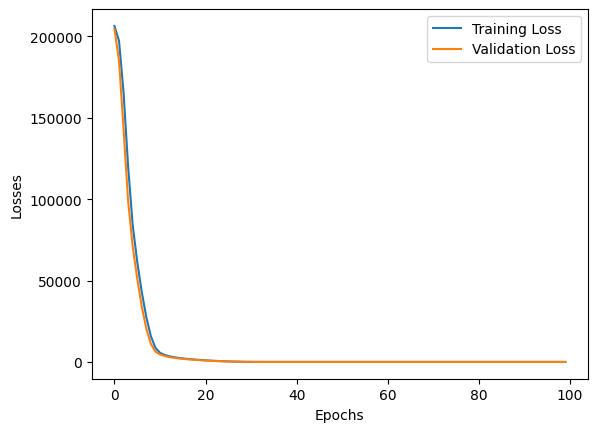

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
#Evalute model

In [ ]:
model.eval()
with torch.no_grad():
  train_preds=model(X_train_torch)
  test_preds=model(X_test_torch)
  train_mse_loss=Criterion(train_preds,y_train_torch)
  test_mse_loss=Criterion(test_preds,y_test_torch)
  print("Training MSE:",train_mse_loss.item())
  print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.786888122558594
Testing MSE: 18.954843521118164


In [26]:
from sklearn.metrics import r2_score
print("r^2 score=",r2_score(y_test,test_preds))

r^2 score= 0.9337577140926785


In [27]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.181671,433.27
1,436.822723,438.16
2,461.242096,458.42
3,476.134735,480.82
4,435.427032,441.41
...,...,...
1909,451.108246,456.70
1910,431.539734,438.04
1911,467.458618,467.80
1912,431.006470,437.14
